In [9]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tracklab import ExperimentReader

# Save figure as svg
# path = Path('../../presentation/public/fig/')
path = Path('./')
# Make sure the directory exists
path.mkdir(parents=True, exist_ok=True)

# Plot config

In [2]:
"""
Script to set up the configurations for the plots.
"""
# Define font sizes
FONTSIZES = {
    'xxs': 4,
    'xs': 6,
    's': 8,
    'm': 10,
    'l': 12,
    'xl': 14,
    'xxl': 16
}

double_w = 7.2  # Width for double column
single_w = 3.5  # Width for single column

def set_font_sizes(conf='normal', factor=1, sizes=None):
    """
    Set font sizes for plots.
    """
    keys = ['font.size', 'axes.labelsize', 'axes.titlesize',
            'xtick.labelsize', 'ytick.labelsize',
            'legend.fontsize', 'figure.titlesize']
    
    if conf == 'normal':
        sizes = ['m', 'm', 'm', 's', 's', 's', 'l']
    elif conf == 'equal':
        sizes = ['m', 'm', 'm', 'm', 'm', 'm', 'm']
    elif conf == 'tight':
        sizes = ['s', 'm', 'm', 'xs', 'xs', 'xs', 'm']
    elif conf == 'custom':
        if sizes is None:
            raise ValueError("Must specify list of sizes (e.g., ['m', 'm', 'm', 's', 's', 's', 'l'])")
    
    for size, key in zip(sizes, keys):
        plt.rcParams[key] = FONTSIZES[size] * factor


def apply_general_styles():
    """
    Apply general plot styles.
    """
    plt.rcParams.update({
        'mathtext.fontset': 'cm',
        'font.family': 'STIXGeneral',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.dpi': 150,
        'text.usetex': False,
        'text.latex.preamble': r'\usepackage{amsmath,amssymb}'
    })


def create_fig(nrows=1,ncols=1,size='single',w=1.0,h=0.5,layout='constrained',sharex=True,sharey=None,w_ratios=None,h_ratios=None):
    width = single_w if size=='single' else double_w
    figsize = (w*width,h*width)
    fig , axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=figsize,layout=layout,sharex=sharex,sharey=sharey,gridspec_kw={'width_ratios': w_ratios, 'height_ratios': h_ratios})
    return fig , axes

apply_general_styles()
set_font_sizes(conf='tight')

# Code


In [ ]:
# Examples of log files that can be found in the experiment directory

# Example of last 3 lines in a log that finished the training steps
# 2026-09-20 15:16:43,641 - INFO - step 860/860 | loss=4.8519 | top1_accuracy=0.0154
# 2026-09-20 15:16:43,641 - INFO - training done at step 860
# 2026-09-20 15:16:43,641 - INFO - elapsed time = (0.58 min) = (0.01 hr)for 860 steps (40.6 ms/step) = (0.0406 s/step)



# Example of last 3 lines in a log that stopped early due to accuracy > 0.75
# 2026-09-20 15:11:44,643 - INFO - early stop at step 1887: top1_accuracy=0.8060 >= 0.75
# 2026-09-20 15:11:44,644 - INFO - training stopped at step 1887
# 2026-09-20 15:11:44,644 - INFO - elapsed time = (0.59 min) = (0.01 hr)for 1887 steps (18.8 ms/step) = (0.0188 s/step)

# Example of last 3 lines in a log that stopped early due to loss=nan
# 2026-09-20 15:26:57,242 - INFO - step 86/217 | loss=nan | top1_accuracy=0.0000
# 2026-09-20 15:26:57,242 - INFO - training stopped at step 86
# 2026-09-20 15:26:57,243 - INFO - elapsed time = (0.04 min) = (0.00 hr)for 86 steps (26.0 ms/step) = (0.0260 s/step)

## Useful functions

In [14]:
def get_log_info(base_dir, experiment_name, run_id):
    """
    Read the last line of the log file manually. The file is located in base_dir/experiment_name/run_id/logs/info.log
    Returns the last line, elapsed time in minutes, and seconds per step.
    """
    log_file_path = Path(base_dir) / experiment_name / run_id / 'logs' / 'info.log'

    last = None
    if log_file_path.exists():
        with open(log_file_path, 'r') as f:
            lines = f.read().splitlines()
        last = lines[-1] if lines else None

    if last is not None:
        m = re.search(r"\(([\d.]+) min\).*?\(([\d.]+) s/step\)", last)
        minutes, sec_per_step = float(m.group(1)), float(m.group(2))  
    return last, minutes, sec_per_step

In [33]:
experiment_name = 'eta_corners'
base_dir = '../data'
reader = ExperimentReader(experiment_name,base_dir=base_dir)
summary = reader.summarize_runs()


summary['T'] = None
summary['explode'] = None
summary['actual_steps'] = None
summary['elapsed_time_min'] = None
summary['sec_per_step'] = None

for i in range(len(summary)):
    row = summary.iloc[i]
    run_id = row['run_id']
    metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
    summary.loc[i,'actual_steps'] = metrics['step'].max()
    # Check for nans in the metrics at the last step and flag the run with explode = True if any nans are found
    if metrics.iloc[-1].isnull().any():
        summary.loc[i,'explode'] = True
    else:
        summary.loc[i,'explode'] = False

    # Read the elapsed time and seconds per step from the log file
    last_line, elapsed_time_min, sec_per_step = get_log_info(base_dir, experiment_name, run_id)
    summary.loc[i,'elapsed_time_min'] = elapsed_time_min
    summary.loc[i,'sec_per_step'] = sec_per_step


    idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
    if len(idx_transition) > 0:
        T_transition = metrics['step'][idx_transition[0]]
        summary.loc[i,'T'] = T_transition

summary['steps_completed'] = summary['actual_steps'] >= summary['total_steps']

# # Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
# filtered_summary = summary[summary['T'].notnull()].copy()


# filtered_summary = filtered_summary[~filtered_summary['run_id'].isin(runs_out)]

# print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].tail())

# # Replace nans with 0 in the filtered_summary dataframe
# filtered_summary.fillna(0, inplace=True)

# # Group all runs with same vocab_size & seq_len and compute mean and std of T
# grouped = filtered_summary.groupby(['vocab_size','seq_len','d_model'])['T'].agg(['mean','std']).reset_index()
# print(grouped)

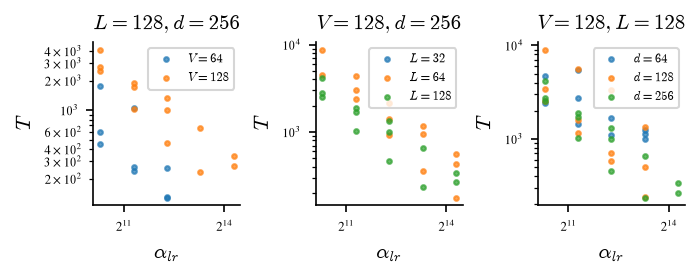

In [50]:
# V128 L128 d256
V_base = 128
L_base = 128
d_base = 256

fig , axes = create_fig(ncols=3,w=1.3)

# Variable V
ax = axes[0]

data = summary[(summary['seq_len']==L_base) & (summary['d_model']==d_base)]
for V in sorted(data['vocab_size'].unique()):
    subset = data[data['vocab_size']==V]
    ax.scatter(subset['alpha_lr'], subset['T'], label=fr'$V={V}$', alpha=0.7,s=5)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$L={L_base}, d={d_base}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()

# Variable L
ax = axes[1]
data = summary[(summary['vocab_size']==V_base) & (summary['d_model']==d_base)]
for L in sorted(data['seq_len'].unique()):
    subset = data[data['seq_len']==L]
    ax.scatter(subset['alpha_lr'], subset['T'], label=fr'$L={L}$', alpha=0.7,s=5)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, d={d_base}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()

# Variable d
ax = axes[2]
data = summary[(summary['vocab_size']==V_base) & (summary['seq_len']==L_base)]
for d in sorted(data['d_model'].unique()):
    subset = data[data['d_model']==d]
    ax.scatter(subset['alpha_lr'], subset['T'], label=fr'$d={d}$', alpha=0.7,s=5)   

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, L={L_base}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.legend()
    

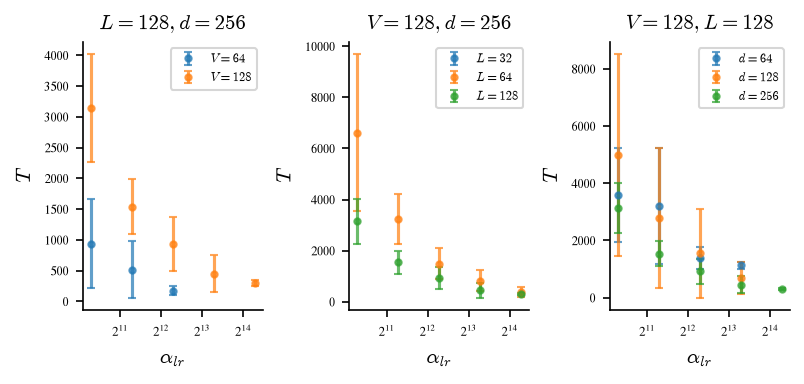

In [55]:
# V128 L128 d256
V_base = 128
L_base = 128
d_base = 256

fig , axes = create_fig(ncols=3,w=1.5,h=0.7)

# Variable V
ax = axes[0]

data = summary[(summary['seq_len']==L_base) & (summary['d_model']==d_base)]
for V in sorted(data['vocab_size'].unique()):
    subset = data[data['vocab_size']==V]
    ax.errorbar(subset['alpha_lr'].unique(), subset.groupby('alpha_lr')['T'].mean(), yerr=subset.groupby('alpha_lr')['T'].std(), label=fr'$V={V}$', alpha=0.7, fmt='o', markersize=3, capsize=2)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$L={L_base}, d={d_base}$')
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend()

# Variable L
ax = axes[1]
data = summary[(summary['vocab_size']==V_base) & (summary['d_model']==d_base)]
for L in sorted(data['seq_len'].unique()):
    subset = data[data['seq_len']==L]
    ax.errorbar(subset['alpha_lr'].unique(), subset.groupby('alpha_lr')['T'].mean(), yerr=subset.groupby('alpha_lr')['T'].std(), label=fr'$L={L}$', alpha=0.7, fmt='o', markersize=3, capsize=2)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, d={d_base}$')
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend()

# Variable d
ax = axes[2]
data = summary[(summary['vocab_size']==V_base) & (summary['seq_len']==L_base)]
for d in sorted(data['d_model'].unique()):
    subset = data[data['d_model']==d]
    ax.errorbar(subset['alpha_lr'].unique(), subset.groupby('alpha_lr')['T'].mean(), yerr=subset.groupby('alpha_lr')['T'].std(), label=fr'$d={d}$', alpha=0.7, fmt='o', markersize=3, capsize=2)

ax.set_xlabel(r'$\alpha_{lr}$')
ax.set_ylabel(r'$T$')
ax.set_title(fr'$V={V_base}, L={L_base}$')
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend()
    

In [47]:
summary['alpha_lr'].unique()

array([ 1250.,  2500.,  5000., 10000., 20000.])

In [48]:
summary[summary['alpha_lr'] == 5000.0]

,run_id,vocab_size,d_model,seq_len,batch_size,K,alpha_lr,lr,total_steps,seed,T,explode,actual_steps,elapsed_time_min,sec_per_step,steps_completed
2,run_003,128,256,128,145,25,5000.0,19.53125,3440,1,1001,False,1001,0.33,0.02,False
6,run_007,128,256,32,1927,25,5000.0,19.53125,1720,1,None,False,1720,1.09,0.0379,True
10,run_011,128,256,64,514,25,5000.0,19.53125,2432,1,2123,False,2123,0.81,0.0229,False
14,run_015,64,256,128,91,12,5000.0,19.53125,870,1,128,False,128,0.05,0.022,False
18,run_019,128,64,128,145,25,5000.0,78.12500,3440,1,1668,False,1737,0.56,0.0194,False
22,run_023,128,128,128,145,25,5000.0,39.06250,3440,1,713,False,725,0.26,0.0216,False
34,run_035,128,256,128,145,25,5000.0,19.53125,3440,2,1323,False,1323,0.44,0.0199,False
35,run_036,128,256,128,145,25,5000.0,19.53125,3440,3,460,False,460,0.15,0.02,False
44,run_045,128,256,32,1927,25,5000.0,19.53125,1720,3,None,False,1720,1.09,0.038,True
45,run_046,128,256,32,1927,25,5000.0,19.53125,1720,2,None,False,1720,1.09,0.038,True


In [37]:
# Check where T is none
summary[~summary['T'].isnull()]

,run_id,vocab_size,d_model,seq_len,batch_size,K,alpha_lr,lr,total_steps,seed,T,explode,actual_steps,elapsed_time_min,sec_per_step,steps_completed
0,run_001,128,256,128,145,25,1250.0,4.882812,13761,1,4142,False,4188,1.35,0.0193,False
1,run_002,128,256,128,145,25,2500.0,9.765625,6880,1,1887,False,1887,0.59,0.0188,False
2,run_003,128,256,128,145,25,5000.0,19.531250,3440,1,1001,False,1001,0.33,0.02,False
3,run_004,128,256,128,145,25,10000.0,39.062500,1720,1,662,False,662,0.22,0.0204,False
9,run_010,128,256,64,514,25,2500.0,9.765625,4865,1,4328,False,4344,1.61,0.0222,False
10,run_011,128,256,64,514,25,5000.0,19.531250,2432,1,2123,False,2123,0.81,0.0229,False
11,run_012,128,256,64,514,25,10000.0,39.062500,1216,1,1159,False,1159,0.46,0.0237,False
12,run_013,64,256,128,91,12,1250.0,4.882812,3482,1,594,False,594,0.19,0.0189,False
13,run_014,64,256,128,91,12,2500.0,9.765625,1741,1,262,False,268,0.09,0.0201,False
14,run_015,64,256,128,91,12,5000.0,19.531250,870,1,128,False,128,0.05,0.022,False


# Sweep

In [60]:
experiment_name = 'scaling_sweep'
base_dir = '../data'
reader = ExperimentReader(experiment_name,base_dir=base_dir)
summary = reader.summarize_runs()


summary['T'] = None
summary['explode'] = None
summary['actual_steps'] = None
summary['elapsed_time_min'] = None
summary['sec_per_step'] = None

for i in range(len(summary)):
    row = summary.iloc[i]
    run_id = row['run_id']
    metrics = reader.load_metrics(run_id).pivot(index='step', columns='metric', values='value').reset_index()
    summary.loc[i,'actual_steps'] = metrics['step'].max()
    # Check for nans in the metrics at the last step and flag the run with explode = True if any nans are found
    if metrics.iloc[-1].isnull().any():
        summary.loc[i,'explode'] = True
    else:
        summary.loc[i,'explode'] = False

    # Read the elapsed time and seconds per step from the log file
    # last_line, elapsed_time_min, sec_per_step = get_log_info(base_dir, experiment_name, run_id)
    # summary.loc[i,'elapsed_time_min'] = elapsed_time_min
    # summary.loc[i,'sec_per_step'] = sec_per_step


    idx_transition = np.where(metrics['top1_accuracy']>0.5)[0]
    if len(idx_transition) > 0:
        T_transition = metrics['step'][idx_transition[0]]
        summary.loc[i,'T'] = T_transition

summary['steps_completed'] = summary['actual_steps'] >= summary['total_steps']

# # Filter out runs that did not reach the transition on a copy dataframe to avoid SettingWithCopyWarning
# filtered_summary = summary[summary['T'].notnull()].copy()


# filtered_summary = filtered_summary[~filtered_summary['run_id'].isin(runs_out)]

# print(filtered_summary[['run_id','vocab_size','d_model','seq_len','T']].tail())

# # Replace nans with 0 in the filtered_summary dataframe
# filtered_summary.fillna(0, inplace=True)

# # Group all runs with same vocab_size & seq_len and compute mean and std of T
# grouped = filtered_summary.groupby(['vocab_size','seq_len','d_model'])['T'].agg(['mean','std']).reset_index()
# print(grouped)

In [61]:
summary

,run_id,vocab_size,d_model,seq_len,batch_size,K,lr,total_steps,seed,T,explode,actual_steps,elapsed_time_min,sec_per_step,steps_completed
0,run_001,128,256,128,145,25,13.671875,12287,1,1356,False,1356,None,None,False
1,run_002,128,256,128,145,25,13.671875,12287,2,1479,False,1479,None,None,False
2,run_003,128,256,32,1927,25,13.671875,6143,1,None,False,6143,None,None,True
3,run_004,128,256,32,1927,25,13.671875,6143,2,3513,False,3534,None,None,False
4,run_005,128,256,64,514,25,13.671875,8688,1,3283,False,3283,None,None,False
5,run_006,128,256,64,514,25,13.671875,8688,2,1540,False,1569,None,None,False
6,run_007,128,256,256,45,25,13.671875,17376,1,3312,False,3312,None,None,False
7,run_008,128,256,256,45,25,13.671875,17376,2,755,False,755,None,None,False
8,run_009,32,256,128,65,6,13.671875,777,1,75,False,75,None,None,False
9,run_010,32,256,128,65,6,13.671875,777,2,None,True,78,None,None,False
